In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



#Objetivo aqui é transformar os dados de hiato de produto em um dataframe para melhor trabalhar com os dados

data_gap = pd.read_excel("gap.xlsx", header=2)
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano = gap_ano.set_index('Quarterly')
gap_ano.index.name = 'Year'



C:\Users\tgu12\AppData\Local\Temp\ipykernel_26548\2249964920.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)


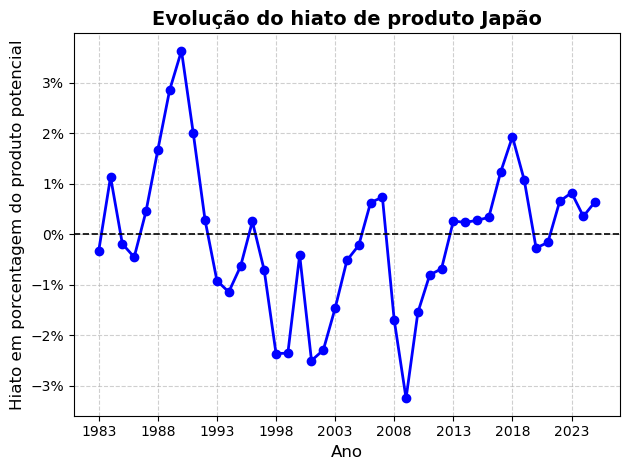

In [77]:
#Gráfico:
plt.plot(gap_ano.index,gap_ano['Output gap'], marker = 'o', linestyle = '-', color = 'blue', linewidth = 2)

plt.title('Evolução do hiato de produto Japão', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Hiato em porcentagem do produto potencial', fontsize = 12)
ax = plt.gca()  
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
#Código para mudar a cor quando for negativo:


# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Adiciona uma linha preta tracejada no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.grid(True, linestyle = "--", alpha = 0.6)

#Mostra de 5 em 5 anos:
anos_5_em_5 = range(int(gap_ano.index.min()), int(gap_ano.index.max()) + 1, 5)
plt.xticks(anos_5_em_5)
plt.tight_layout()

plt.savefig("grafico_output_gap.png", dpi = 300)

_Dividir a análise em duas:_


In [78]:
#Primeiro gráfico : de 1983 até 2000
gap_83_00 = gap_ano.loc[1983:2000]

#Segundo gráfico: 2000 até 2025
gap_00_25 = gap_ano.loc[2000:2025]


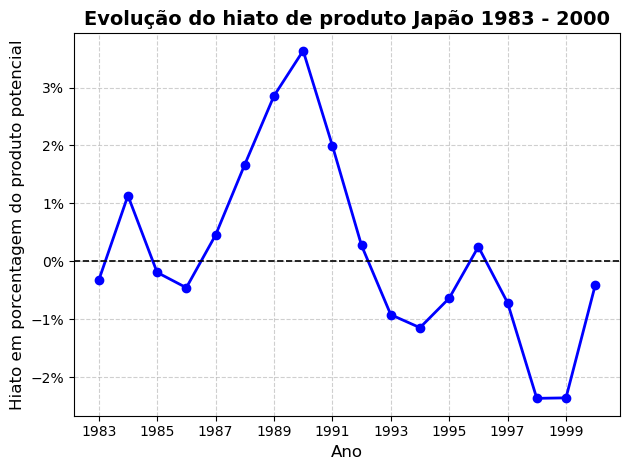

In [79]:
plt.plot(gap_83_00.index,gap_83_00['Output gap'], marker = 'o', linestyle = '-', color = 'blue', linewidth = 2)

plt.title('Evolução do hiato de produto Japão 1983 - 2000', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Hiato em porcentagem do produto potencial', fontsize = 12)
ax = plt.gca()  
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
#Código para mudar a cor quando for negativo:


# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Adiciona uma linha preta tracejada no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.grid(True, linestyle = "--", alpha = 0.6)

#Mostra de 5 em 5 anos:
anos_2_em_2 = range(int(gap_83_00.index.min()), int(gap_83_00.index.max()) + 1, 2)
plt.xticks(anos_2_em_2)
plt.tight_layout()

plt.savefig("grafico_output_gap_83-00.png", dpi = 300)

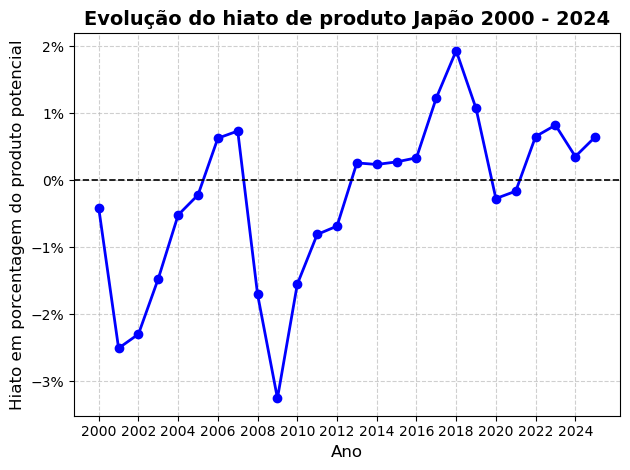

In [80]:
plt.plot(gap_00_25.index,gap_00_25['Output gap'], marker = 'o', linestyle = '-', color = 'blue', linewidth = 2)

plt.title('Evolução do hiato de produto Japão 2000 - 2024', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Hiato em porcentagem do produto potencial', fontsize = 12)
ax = plt.gca()  
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
#Código para mudar a cor quando for negativo:


# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Adiciona uma linha preta tracejada no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.grid(True, linestyle = "--", alpha = 0.6)

#Mostra de 2 em 2 anos:
anos_2_em_2 = range(int(gap_00_25.index.min()), int(gap_00_25.index.max()) + 1, 2)
plt.xticks(anos_2_em_2)
plt.tight_layout()

plt.savefig("grafico_output_gap_00-24.png", dpi = 300)

_TAXA DE JUROS_

In [81]:
#Gráfico Baseado nas estimativas do modelo de Goy and Iwasaki (2024)

tx_juros = pd.read_excel("natural_interest_rate_japan.xlsx",header = 2)
tx_juros = tx_juros[["Unnamed: 2", "Goy and Iwasaki (2024)"]]

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
tx_n_y = tx_juros[tx_juros['Unnamed: 2'].str.contains('Q4$', na = False)]
tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
# 1. Renomeia as colunas corretamente usando o método .rename()
tx_n_y = tx_n_y.rename(columns={
    'Unnamed: 2': 'Year',
    'Goy and Iwasaki (2024)': 'Natural interest rate'
})

# 2. Transforma os anos no novo índice do DataFrame
tx_n_y = tx_n_y.set_index('Year')


tx_n_y.tail(), tx_n_y.head()



C:\Users\tgu12\AppData\Local\Temp\ipykernel_26548\3736085198.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)


(      Natural interest rate
 Year                       
 2020              -0.701056
 2021              -0.753173
 2022              -0.841298
 2023              -1.005236
 2024              -0.972300,
       Natural interest rate
 Year                       
 1992                    NaN
 1993               0.885443
 1994               0.677270
 1995               0.210731
 1996               0.044659)

_Plotando gráfico_

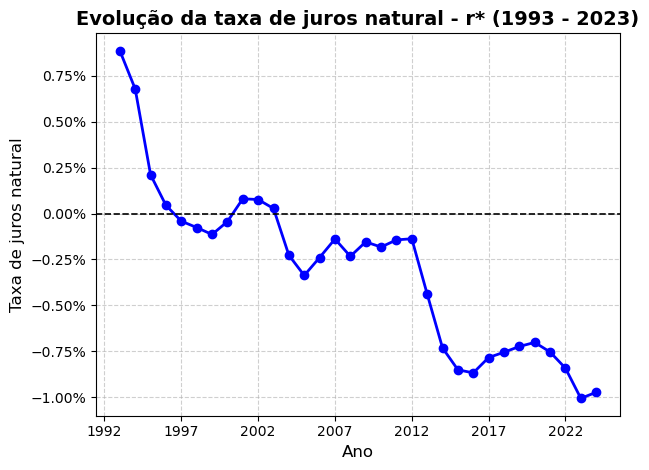

In [88]:
#Gráfico geral:
plt.plot(tx_n_y.index,tx_n_y['Natural interest rate'], marker = 'o', linestyle = '-', color = 'blue', linewidth = 2)

plt.title('Evolução da taxa de juros natural - r* (1993 - 2023)', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Taxa de juros natural', fontsize = 12)
ax = plt.gca()  
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))



# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Adiciona uma linha preta tracejada no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.grid(True, linestyle = "--", alpha = 0.6)

#Mostra de 5 em 5 anos:
anos_5_em_5 = range(int(tx_n_y.index.min()), int(tx_n_y.index.max()) + 1, 5)
plt.xticks(anos_5_em_5)
plt.tight_layout()

plt.savefig("grafico_geral_natural_interest_rate.png", dpi = 300)

In [83]:
#Primeiro gráfico : de 1993 até 2000
tx_n_93_00 = tx_n_y.loc[1993:2000]
#Segundo gráfico: 2000 até 2023
tx_n_00_23 = tx_n_y.loc[2000:2023]


EVOLUÇÃO TAXA DE JUROS NATURAL DE 1993 - 2000


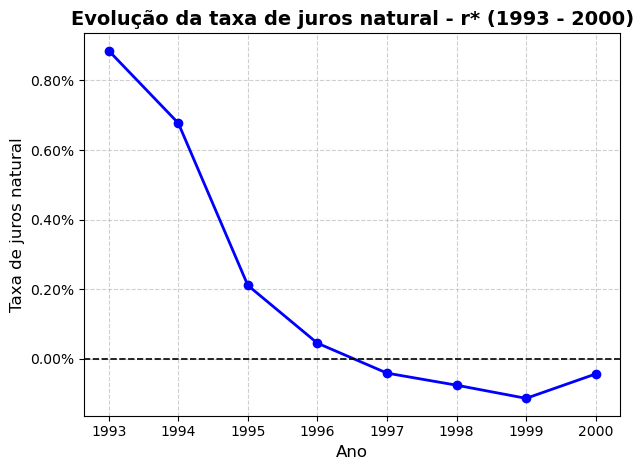

In [86]:
#Gráfico 1993-2000:
plt.plot(tx_n_93_00.index,tx_n_93_00['Natural interest rate'], marker = 'o', linestyle = '-', color = 'blue', linewidth = 2)

plt.title('Evolução da taxa de juros natural - r* (1993 - 2000)', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Taxa de juros natural', fontsize = 12)
ax = plt.gca()  
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))



# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Adiciona uma linha preta tracejada no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.grid(True, linestyle = "--", alpha = 0.6)

#Mostra de 2 em 2 anos:
anos_1_em_1= range(int(tx_n_93_00.index.min()), int(tx_n_93_00.index.max()) + 1, 1)
plt.xticks(anos_1_em_1)
plt.tight_layout()

plt.savefig("grafico_geral_natural_interest_rate_93-00.png", dpi = 300)

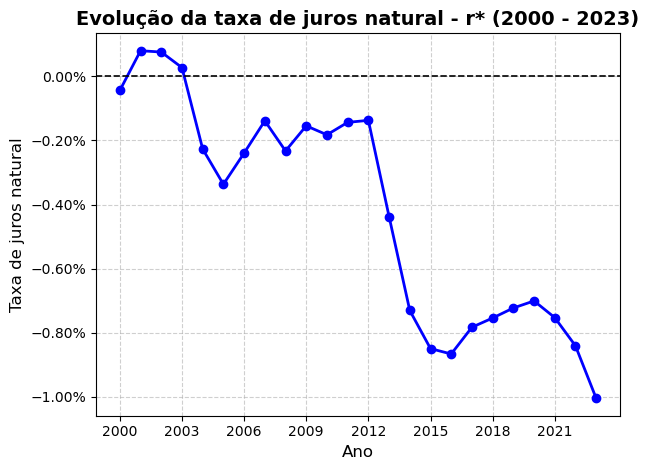

In [85]:
#Gráfico 2000-2023:
plt.plot(tx_n_00_23.index,tx_n_00_23['Natural interest rate'], marker = 'o', linestyle = '-', color = 'blue', linewidth = 2)

plt.title('Evolução da taxa de juros natural - r* (2000 - 2023)', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Taxa de juros natural', fontsize = 12)
ax = plt.gca()  
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))



# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Adiciona uma linha preta tracejada no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.grid(True, linestyle = "--", alpha = 0.6)

#Mostra de 3 em 3 anos:
anos_3_em_3= range(int(tx_n_00_23.index.min()), int(tx_n_00_23.index.max()) + 1, 3)
plt.xticks(anos_3_em_3)
plt.tight_layout()

plt.savefig("grafico_geral_natural_interest_rate_00-23.png", dpi = 300)